# Systematic Market Regime Detection & Cross-Asset Analysis

**Unsupervised Machine Learning | PCA | K-Means | Macroeconomic & Financial Markets**

## Research Question

Can unsupervised machine learning identify economically meaningful market regimes from macroeconomic and cross-asset financial indicators, and do major asset classes exhibit systematically different behavior across those regimes?

## Executive Summary

This project applies **Principal Component Analysis (PCA)** and **K-Means clustering** to 13 macroeconomic and cross-asset features covering U.S. equities, volatility, Treasury bonds, gold, commodities, the U.S. dollar, inflation, unemployment, monetary policy, and the yield curve.

Using 4,681 daily observations from 2007–2025, PCA reduces the feature space from 13 variables to 7 principal components while retaining **92.21% of total variance**. Silhouette analysis identifies a **three-regime structure**:

1. **Low-Volatility / Risk-On**
2. **Inflationary / Tight Monetary**
3. **Crisis / Severe Risk-Off**

The regimes exhibit substantially different cross-asset behavior. SPY performs strongest during Risk-On conditions, gold performs particularly well during Inflationary / Tight Monetary conditions, and long-term U.S. Treasuries perform strongly during Crisis conditions.

The model also classifies the Lehman Brothers bankruptcy, the 2011 U.S. credit downgrade, and the March 2020 COVID crash as Crisis / Severe Risk-Off periods.

## Methodology

**Market & Macro Data → Feature Engineering → Data Alignment → Standardization → PCA → Cluster Selection → K-Means → Economic Interpretation → Historical Validation → Cross-Asset Analysis**

## Data

**Market data:** Yahoo Finance  
**Macroeconomic data:** Federal Reserve Economic Data (FRED)

### Model Inputs

The final dataset contains **13 features** spanning:

- Equity momentum and realized volatility
- VIX market volatility
- Treasury, gold, commodity, and U.S. dollar momentum
- Inflation and unemployment
- Federal Funds Rate
- 10-Year and 2-Year Treasury yields
- 10Y–2Y yield-curve spread

In [1]:
!pip install -q yfinance fredapi

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from getpass import getpass
from fredapi import Fred

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## 1. Market Data Collection

Daily market data are collected across several major asset classes and market indicators:

- **SPY** — U.S. equities / S&P 500
- **TLT** — long-term U.S. Treasury bonds
- **GLD** — gold
- **DBC** — broad commodities
- **UUP** — U.S. dollar
- **VIX** — expected U.S. equity-market volatility

Using multiple asset classes allows the regime model to capture broader financial conditions rather than relying exclusively on equity-market behavior.

Data are downloaded beginning in 2005 to provide sufficient history for rolling feature calculations. The final modeling sample begins later because DBC and UUP have shorter trading histories.

In [3]:
tickers = [
    "SPY",   # U.S. equities
    "TLT",   # Long-term U.S. Treasuries
    "GLD",   # Gold
    "DBC",   # Broad commodities
    "UUP",   # U.S. dollar
    "^VIX"   # Equity-market volatility
]

market_data = yf.download(
    tickers,
    start="2005-01-01",
    end="2026-01-01",
    auto_adjust=True
)

prices = market_data["Close"]

print("Market data downloaded successfully.")
print("Dataset shape:", prices.shape)

prices.head()

[*********************100%***********************]  6 of 6 completed

Market data downloaded successfully.
Dataset shape: (5283, 6)


Ticker,DBC,GLD,SPY,TLT,UUP,^VIX
Date,,,,,,
2005-01-03,NaN,43.020000,81.174583,43.715523,NaN,14.08
2005-01-04,NaN,42.740002,80.182716,43.257401,NaN,13.98
2005-01-05,NaN,42.669998,79.629372,43.488873,NaN,14.09
2005-01-06,NaN,42.150002,80.034264,43.518448,NaN,13.58
2005-01-07,NaN,41.840000,79.919479,43.617016,NaN,13.49


In [4]:
returns = prices.pct_change(fill_method=None)

returns.head()

Ticker,DBC,GLD,SPY,TLT,UUP,^VIX
Date,,,,,,
2005-01-03,NaN,NaN,NaN,NaN,NaN,NaN
2005-01-04,NaN,-0.006509,-0.012219,-0.010480,NaN,-0.007102
2005-01-05,NaN,-0.001638,-0.006901,0.005351,NaN,0.007868
2005-01-06,NaN,-0.012186,0.005085,0.000680,NaN,-0.036196
2005-01-07,NaN,-0.007355,-0.001434,0.002265,NaN,-0.006627


## 2. Market Feature Engineering

Daily returns are first calculated from adjusted closing prices.

The model then constructs seven market-based features:

- **SPY 60-day momentum** — recent equity-market trend
- **SPY 30-day realized volatility** — recent equity-market turbulence
- **VIX level** — expected near-term equity-market volatility
- **TLT 60-day momentum** — long-term Treasury trend
- **GLD 60-day momentum** — gold trend
- **DBC 60-day momentum** — commodity trend
- **UUP 60-day momentum** — U.S. dollar trend

These variables summarize direction, volatility, and cross-asset behavior across major markets.

In [5]:
returns = prices.pct_change(fill_method=None)

market_features = pd.DataFrame({
    "SPY_Momentum_60D": prices["SPY"].pct_change(60),
    "SPY_Volatility_30D": returns["SPY"].rolling(30).std(),
    "VIX_Level": prices["^VIX"],
    "TLT_Momentum_60D": prices["TLT"].pct_change(60),
    "GLD_Momentum_60D": prices["GLD"].pct_change(60),
    "DBC_Momentum_60D": prices["DBC"].pct_change(60),
    "UUP_Momentum_60D": prices["UUP"].pct_change(60)
})

market_features.head()

,SPY_Momentum_60D,SPY_Volatility_30D,VIX_Level,TLT_Momentum_60D,GLD_Momentum_60D,DBC_Momentum_60D,UUP_Momentum_60D
Date,,,,,,,
2005-01-03,NaN,NaN,14.08,NaN,NaN,NaN,NaN
2005-01-04,NaN,NaN,13.98,NaN,NaN,NaN,NaN
2005-01-05,NaN,NaN,14.09,NaN,NaN,NaN,NaN
2005-01-06,NaN,NaN,13.58,NaN,NaN,NaN,NaN
2005-01-07,NaN,NaN,13.49,NaN,NaN,NaN,NaN


## 3. Macroeconomic Data Collection

Macroeconomic data are collected from the Federal Reserve Economic Data (FRED) database.

The model incorporates:

- **Inflation YoY** — year-over-year change in the Consumer Price Index
- **Unemployment Rate** — labor-market conditions
- **Federal Funds Rate** — monetary-policy conditions
- **10-Year Treasury Yield** — long-term interest rates
- **2-Year Treasury Yield** — shorter-term interest rates
- **Yield Curve Spread** — difference between the 10-year and 2-year Treasury yields

Monthly macroeconomic variables are lagged by one monthly observation as a conservative approximation of information availability and to reduce look-ahead bias. Daily Treasury yields are retained at their observed frequency.

In [6]:
FRED_API_KEY = getpass("Enter your FRED API key: ")

fred = Fred(api_key=FRED_API_KEY)

print("FRED connected successfully.")

Enter your FRED API key: ··········
FRED connected successfully.


In [7]:
# Download macroeconomic and interest-rate series from FRED

cpi = fred.get_series("CPIAUCSL")
unemployment = fred.get_series("UNRATE")
fed_funds = fred.get_series("FEDFUNDS")
ten_year = fred.get_series("DGS10")
two_year = fred.get_series("DGS2")

# Calculate year-over-year inflation
inflation_yoy = cpi.pct_change(
    periods=12,
    fill_method=None
)

print("Macroeconomic data downloaded successfully.")

Macroeconomic data downloaded successfully.


In [8]:
# Construct monthly macroeconomic dataset

monthly_macro = pd.concat(
    [
        inflation_yoy.rename("Inflation_YoY"),
        unemployment.rename("Unemployment"),
        fed_funds.rename("Fed_Funds_Rate")
    ],
    axis=1
)

# Lag monthly observations by one month to reduce look-ahead bias
monthly_macro_lagged = monthly_macro.shift(1)

monthly_macro_lagged.loc["2004-01-01":"2005-06-01"].head()

,Inflation_YoY,Unemployment,Fed_Funds_Rate
2004-01-01,0.020352,5.7,0.98
2004-02-01,0.020263,5.7,1.00
2004-03-01,0.016885,5.6,1.01
2004-04-01,0.017401,5.8,1.00
2004-05-01,0.022926,5.6,1.00


In [9]:
# Construct daily Treasury-rate dataset

daily_rates = pd.concat(
    [
        ten_year.rename("10Y_Yield"),
        two_year.rename("2Y_Yield")
    ],
    axis=1
)

# Calculate the 10Y-2Y yield curve spread
daily_rates["Yield_Curve_Spread"] = (
    daily_rates["10Y_Yield"]
    - daily_rates["2Y_Yield"]
)

daily_rates.loc["2004-01-01":"2005-06-01"].head()

,10Y_Yield,2Y_Yield,Yield_Curve_Spread
2004-01-01,NaN,NaN,NaN
2004-01-02,4.38,1.94,2.44
2004-01-05,4.41,1.95,2.46
2004-01-06,4.29,1.84,2.45
2004-01-07,4.27,1.84,2.43


In [10]:
# Define the market trading-day calendar
trading_days = prices.index

# Combine lagged monthly macro data with daily Treasury data
macro_data = pd.concat(
    [
        monthly_macro_lagged,
        daily_rates
    ],
    axis=1
)

# Keep sufficient pre-2005 history for forward-filling
macro_data = macro_data.loc["2004-01-01":"2025-12-31"]

# Align macroeconomic data to market trading days
macro_daily = (
    macro_data
    .reindex(macro_data.index.union(trading_days))
    .sort_index()
    .ffill()
    .reindex(trading_days)
)

macro_daily.head()

,Inflation_YoY,Unemployment,Fed_Funds_Rate,10Y_Yield,2Y_Yield,Yield_Curve_Spread
Date,,,,,,
2005-01-03,0.033423,5.4,2.16,4.23,3.10,1.13
2005-01-04,0.033423,5.4,2.16,4.29,3.20,1.09
2005-01-05,0.033423,5.4,2.16,4.29,3.22,1.07
2005-01-06,0.033423,5.4,2.16,4.29,3.18,1.11
2005-01-07,0.033423,5.4,2.16,4.29,3.20,1.09


In [11]:
print("Missing values in aligned macro dataset:")
print(macro_daily.isna().sum())

print("\nDataset shape:", macro_daily.shape)

Missing values in aligned macro dataset:
Inflation_YoY         0
Unemployment          0
Fed_Funds_Rate        0
10Y_Yield             0
2Y_Yield              0
Yield_Curve_Spread    0
dtype: int64

Dataset shape: (5283, 6)


## 4. Final Modeling Dataset

The seven market-based features are combined with six macroeconomic and interest-rate features to create the final **13-feature modeling dataset**.

Observations with incomplete feature values are removed before standardization, PCA, and clustering. This primarily removes early observations affected by rolling lookback periods and the later inception dates of certain ETFs.

The resulting dataset contains only dates for which all 13 model inputs are available.

In [12]:
# Combine market and macroeconomic features

final_features = market_features.join(
    macro_daily,
    how="inner"
)

# Remove observations with incomplete feature values
final_features = final_features.dropna().copy()

print("Final dataset shape:", final_features.shape)
print("Number of features:", final_features.shape[1])

final_features.head()

Final dataset shape: (4681, 13)
Number of features: 13


,SPY_Momentum_60D,SPY_Volatility_30D,VIX_Level,TLT_Momentum_60D,GLD_Momentum_60D,DBC_Momentum_60D,UUP_Momentum_60D,Inflation_YoY,Unemployment,Fed_Funds_Rate,10Y_Yield,2Y_Yield,Yield_Curve_Spread
Date,,,,,,,,,,,,,
2007-05-25,0.083849,0.005262,13.34,-0.030554,-0.013370,0.022773,-0.002403,0.025929,4.5,5.25,4.86,4.85,0.01
2007-05-29,0.102213,0.005057,13.53,-0.035502,0.021347,0.009678,-0.001603,0.025929,4.5,5.25,4.88,4.88,0.00
2007-05-30,0.121869,0.005207,12.83,-0.035097,0.028444,0.034793,-0.006370,0.025929,4.5,5.25,4.88,4.89,-0.01
2007-05-31,0.101848,0.005226,13.05,-0.033993,0.021668,0.034469,-0.007172,0.025929,4.5,5.25,4.90,4.92,-0.02
2007-06-01,0.108420,0.005257,12.78,-0.042790,0.033281,0.028000,-0.002800,0.027099,4.4,5.25,4.95,4.97,-0.02


## 5. Standardization and Principal Component Analysis

Because the 13 model features are measured on different scales, each variable is standardized to have a mean of zero and a standard deviation of one. This prevents variables with larger numerical scales from disproportionately influencing the analysis.

Principal Component Analysis (PCA) is then used to reduce dimensionality and capture shared variation across correlated market and macroeconomic indicators.

The number of retained components is selected using cumulative explained variance, with a target of preserving at least **90% of the information contained in the standardized feature set**.

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(final_features)

print("Original dimensions:", X_scaled.shape)

Original dimensions: (4681, 13)


In [14]:
# Fit PCA using all components to examine explained variance

pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

for i, variance in enumerate(cumulative_variance, start=1):
    print(f"{i} PCs: {variance:.4f} ({variance * 100:.2f}%)")

1 PCs: 0.3025 (30.25%)
2 PCs: 0.5364 (53.64%)
3 PCs: 0.6685 (66.85%)
4 PCs: 0.7649 (76.49%)
5 PCs: 0.8424 (84.24%)
6 PCs: 0.8877 (88.77%)
7 PCs: 0.9221 (92.21%)
8 PCs: 0.9543 (95.43%)
9 PCs: 0.9726 (97.26%)
10 PCs: 0.9868 (98.68%)
11 PCs: 0.9959 (99.59%)
12 PCs: 1.0000 (100.00%)
13 PCs: 1.0000 (100.00%)


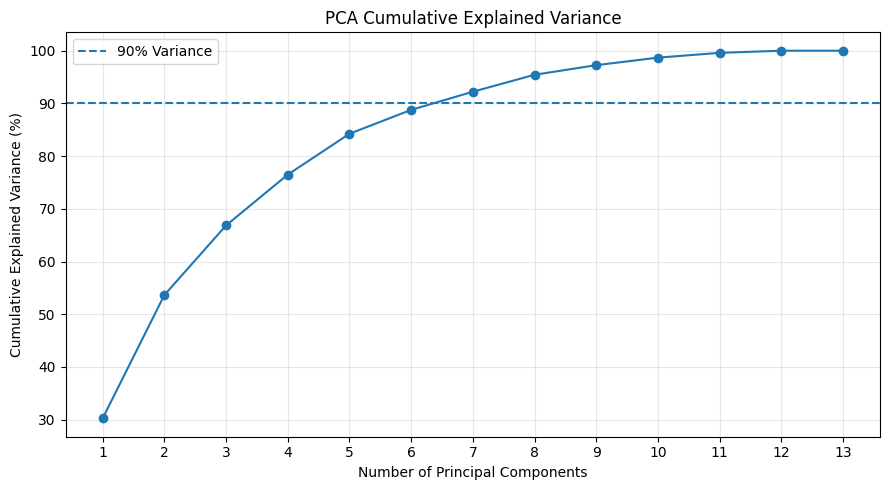

In [15]:
plt.figure(figsize=(9, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance * 100,
    marker="o"
)

plt.axhline(
    y=90,
    linestyle="--",
    label="90% Variance"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("PCA Cumulative Explained Variance")
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# Retain seven principal components

pca = PCA(n_components=7)
X_pca = pca.fit_transform(X_scaled)

variance_retained = pca.explained_variance_ratio_.sum() * 100

print("Original dimensions:", X_scaled.shape)
print("Reduced dimensions:", X_pca.shape)
print("Variance retained:", round(variance_retained, 2), "%")

Original dimensions: (4681, 13)
Reduced dimensions: (4681, 7)
Variance retained: 92.21 %


## 6. Selecting the Number of Market Regimes

K-Means clustering requires the number of clusters to be specified in advance.

To select the number of regimes systematically, models with **2 through 10 clusters** are evaluated using the silhouette score. The silhouette score measures how well observations fit within their assigned cluster relative to other clusters.

Higher scores indicate better-defined separation between regimes.

In [17]:
k_values = range(2, 11)

silhouette_scores = []
inertias = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = model.fit_predict(X_pca)

    inertias.append(model.inertia_)
    silhouette_scores.append(
        silhouette_score(X_pca, labels)
    )

for k, score in zip(k_values, silhouette_scores):
    print(f"k = {k}: {score:.4f}")

k = 2: 0.2755
k = 3: 0.3055
k = 4: 0.2277
k = 5: 0.2455
k = 6: 0.2456
k = 7: 0.2519
k = 8: 0.2420
k = 9: 0.2542
k = 10: 0.2452


In [18]:
best_k = list(k_values)[
    np.argmax(silhouette_scores)
]

best_score = max(silhouette_scores)

print("Best number of clusters:", best_k)
print("Best silhouette score:", round(best_score, 4))

Best number of clusters: 3
Best silhouette score: 0.3055


## 7. K-Means Market Regime Detection

Based on the silhouette analysis, the final model uses **three clusters**.

K-Means clustering is applied to the seven retained principal components. Because cluster numbers have no inherent economic meaning, the resulting regimes are interpreted by examining their average characteristics across the original 13 market and macroeconomic features.

In [19]:
final_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=20
)

final_labels = final_kmeans.fit_predict(X_pca)

final_model_data = final_features.copy()
final_model_data["Regime"] = final_labels

print("Final Regime Counts:")
print(
    final_model_data["Regime"]
    .value_counts()
    .sort_index()
)

Final Regime Counts:
Regime
0    2630
1    1730
2     321
Name: count, dtype: int64


In [20]:
regime_characteristics = (
    final_model_data
    .groupby("Regime")
    .mean()
    .round(3)
)

regime_characteristics

,SPY_Momentum_60D,SPY_Volatility_30D,VIX_Level,TLT_Momentum_60D,GLD_Momentum_60D,DBC_Momentum_60D,UUP_Momentum_60D,Inflation_YoY,Unemployment,Fed_Funds_Rate,10Y_Yield,2Y_Yield,Yield_Curve_Spread
Regime,,,,,,,,,,,,,
0,0.053,0.008,17.731,0.005,0.009,0.017,-0.003,0.017,6.820,0.292,2.234,0.656,1.578
1,0.018,0.010,19.098,-0.002,0.046,0.026,0.009,0.038,4.072,3.492,3.639,3.435,0.205
2,-0.130,0.029,42.870,0.116,0.058,-0.180,0.039,0.022,7.780,0.557,2.437,0.751,1.686


## 8. Economic Interpretation of Market Regimes

The three clusters exhibit distinct economic and financial characteristics:

### Regime 0 — Low-Volatility / Risk-On

Regime 0 exhibits the strongest average equity momentum, relatively low realized equity volatility, and the lowest average VIX among the three clusters. These characteristics are consistent with comparatively favorable conditions for risk assets.

### Regime 1 — Inflationary / Tight Monetary

Regime 1 exhibits the highest average inflation and substantially higher Federal Funds and Treasury rates. These characteristics are consistent with an environment dominated by inflationary pressure and tighter monetary conditions.

### Regime 2 — Crisis / Severe Risk-Off

Regime 2 exhibits sharply negative equity momentum, substantially elevated realized volatility, an average VIX above 40, and severe commodity weakness. These characteristics are consistent with periods of acute financial-market stress.

Cluster numbers are generated algorithmically and have no inherent ordering. The economic labels are assigned after examining the average characteristics of each cluster.

In [21]:
regime_names = {
    0: "Low-Volatility / Risk-On",
    1: "Inflationary / Tight Monetary",
    2: "Crisis / Severe Risk-Off"
}

final_model_data["Regime_Name"] = (
    final_model_data["Regime"]
    .map(regime_names)
)

final_model_data[
    ["Regime", "Regime_Name"]
].head()

,Regime,Regime_Name
Date,,
2007-05-25,1,Inflationary / Tight Monetary
2007-05-29,1,Inflationary / Tight Monetary
2007-05-30,1,Inflationary / Tight Monetary
2007-05-31,1,Inflationary / Tight Monetary
2007-06-01,1,Inflationary / Tight Monetary


## 9. Historical Validation

Because the clustering model is unsupervised, historical events are **not used as labels during model training**. Instead, several well-known periods of financial stress are examined after clustering as an intuitive validation of the resulting regime classifications.

The selected episodes are:

- **Lehman Brothers bankruptcy** — September 15, 2008
- **S&P downgrade of U.S. sovereign credit** — August 8, 2011
- **COVID-19 market crash** — March 16, 2020
- **2022 inflation and Federal Reserve tightening period** — June 15, 2022

A credible regime classification should place the first three episodes within the Crisis / Severe Risk-Off regime and distinguish the inflation-driven 2022 environment from those financial-crisis episodes.

In [22]:
historical_events = {
    "Lehman Bankruptcy": "2008-09-15",
    "S&P U.S. Credit Downgrade": "2011-08-08",
    "COVID Crash": "2020-03-16",
    "2022 Rate-Hike / Inflation Period": "2022-06-15"
}

for event, date in historical_events.items():
    regime = final_model_data.loc[
        pd.Timestamp(date),
        "Regime_Name"
    ]

    print(f"{event}: {date} → {regime}")

Lehman Bankruptcy: 2008-09-15 → Crisis / Severe Risk-Off
S&P U.S. Credit Downgrade: 2011-08-08 → Crisis / Severe Risk-Off
COVID Crash: 2020-03-16 → Crisis / Severe Risk-Off
2022 Rate-Hike / Inflation Period: 2022-06-15 → Inflationary / Tight Monetary


## 10. Market Regimes Through Time

The figure below overlays the model's daily regime classifications on the historical price of SPY.

SPY is used as a visual benchmark for U.S. equity-market performance; the regime classifications themselves are based on the full set of market and macroeconomic features rather than SPY alone.

The shaded regions indicate the market environment identified by the clustering model:

- **Green** — Low-Volatility / Risk-On
- **Orange** — Inflationary / Tight Monetary
- **Red** — Crisis / Severe Risk-Off

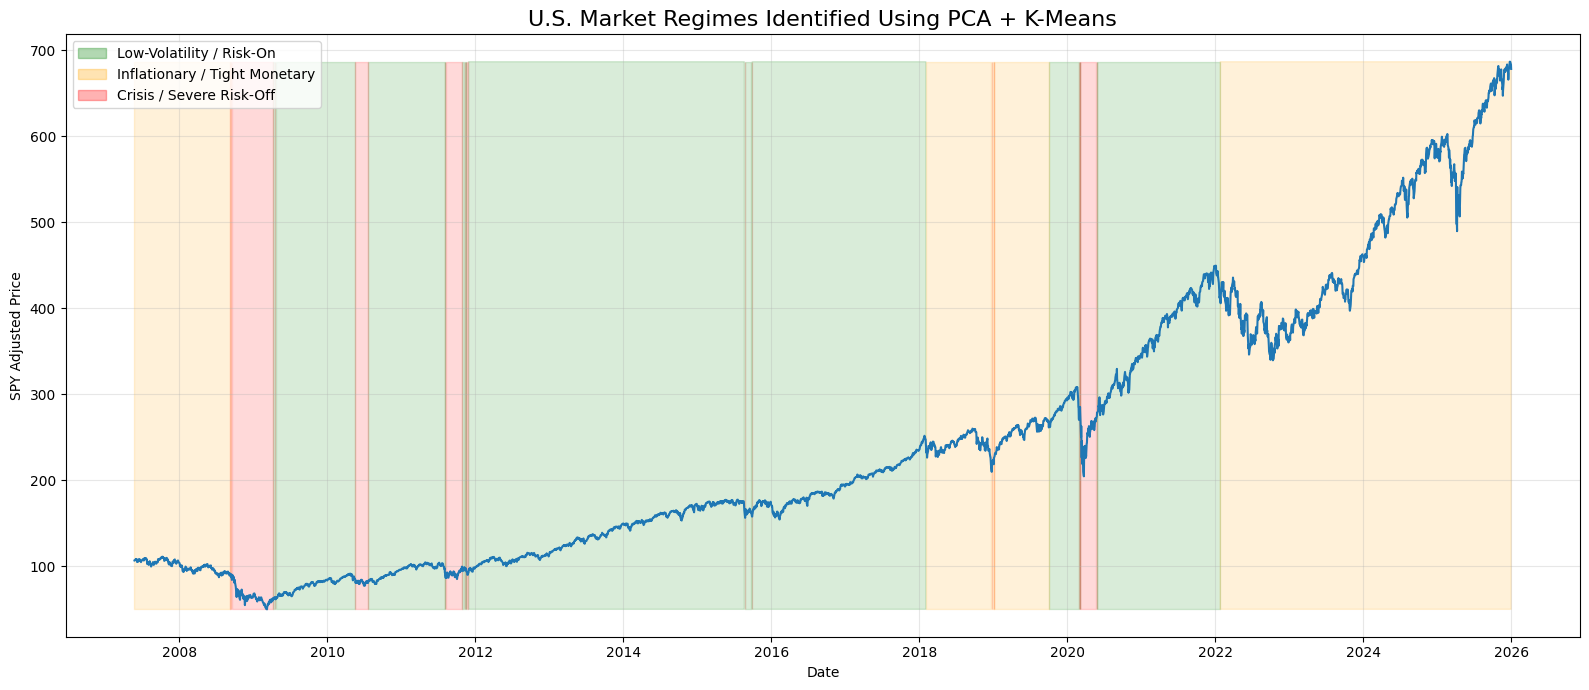

In [23]:
regime_plot = pd.DataFrame(index=final_model_data.index)

regime_plot["SPY"] = prices.loc[
    final_model_data.index,
    "SPY"
]

regime_plot["Regime"] = final_model_data["Regime"]

fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(
    regime_plot.index,
    regime_plot["SPY"],
    linewidth=1.5
)

regime_colors = {
    0: "green",
    1: "orange",
    2: "red"
}

for regime, color in regime_colors.items():
    mask = regime_plot["Regime"] == regime

    ax.fill_between(
        regime_plot.index,
        regime_plot["SPY"].min(),
        regime_plot["SPY"].max(),
        where=mask,
        color=color,
        alpha=0.15
    )

legend_patches = [
    mpatches.Patch(
        color="green",
        alpha=0.3,
        label="Low-Volatility / Risk-On"
    ),
    mpatches.Patch(
        color="orange",
        alpha=0.3,
        label="Inflationary / Tight Monetary"
    ),
    mpatches.Patch(
        color="red",
        alpha=0.3,
        label="Crisis / Severe Risk-Off"
    )
]

ax.set_title(
    "U.S. Market Regimes Identified Using PCA + K-Means",
    fontsize=16
)

ax.set_xlabel("Date")
ax.set_ylabel("SPY Adjusted Price")
ax.legend(
    handles=legend_patches,
    loc="upper left"
)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Cross-Asset Performance Across Market Regimes

To evaluate whether the identified regimes have meaningful implications for asset allocation, daily returns are calculated for five representative asset classes:

- **SPY** — U.S. equities
- **TLT** — long-duration U.S. Treasury bonds
- **GLD** — gold
- **DBC** — broad commodities
- **UUP** — U.S. dollar

For each regime, annualized average return, annualized volatility, and the return-to-volatility ratio are calculated.

These statistics allow us to examine whether different assets exhibit systematically different behavior across the market environments identified by the model.

In [24]:
asset_tickers = [
    "SPY",
    "TLT",
    "GLD",
    "DBC",
    "UUP"
]

asset_returns = (
    prices[asset_tickers]
    .pct_change(fill_method=None)
    .reindex(final_model_data.index)
)

asset_returns["Regime"] = final_model_data["Regime"]

asset_returns.head()

Ticker,SPY,TLT,GLD,DBC,UUP,Regime
Date,,,,,,
2007-05-25,0.004170,-0.002311,0.002934,0.012258,-0.000802,1
2007-05-29,0.003626,-0.000116,0.002002,-0.021875,0.000401,1
2007-05-30,0.008145,0.002084,-0.005379,0.009585,0.001605,1
2007-05-31,-0.001043,-0.001848,0.012670,0.009098,-0.001603,1
2007-06-01,0.004957,-0.005255,0.013732,0.007448,0.000401,1


In [25]:
# Calculate annualized performance statistics by regime

trading_days_per_year = 252

annualized_returns = (
    asset_returns
    .groupby("Regime")[asset_tickers]
    .mean()
    * trading_days_per_year
    * 100
)

annualized_volatility = (
    asset_returns
    .groupby("Regime")[asset_tickers]
    .std()
    * np.sqrt(trading_days_per_year)
    * 100
)

return_volatility_ratio = (
    annualized_returns
    / annualized_volatility
)

# Replace numerical cluster labels with economic regime names
annualized_returns.index = annualized_returns.index.map(regime_names)
annualized_volatility.index = annualized_volatility.index.map(regime_names)
return_volatility_ratio.index = return_volatility_ratio.index.map(regime_names)

print("Annualized Average Return (%)")
display(annualized_returns.round(2))

print("\nAnnualized Volatility (%)")
display(annualized_volatility.round(2))

print("\nReturn-to-Volatility Ratio")
display(return_volatility_ratio.round(2))

Annualized Average Return (%)


Ticker,SPY,TLT,GLD,DBC,UUP
Regime,,,,,
Low-Volatility / Risk-On,22.13,1.11,6.59,7.71,-1.12
Inflationary / Tight Monetary,8.54,1.20,18.17,7.78,5.29
Crisis / Severe Risk-Off,-52.72,46.93,12.69,-71.57,7.17



Annualized Volatility (%)


Ticker,SPY,TLT,GLD,DBC,UUP
Regime,,,,,
Low-Volatility / Risk-On,13.83,13.78,15.52,16.57,7.39
Inflationary / Tight Monetary,17.77,14.51,16.27,18.60,7.73
Crisis / Severe Risk-Off,49.94,26.92,32.72,35.01,14.22



Return-to-Volatility Ratio


Ticker,SPY,TLT,GLD,DBC,UUP
Regime,,,,,
Low-Volatility / Risk-On,1.60,0.08,0.42,0.47,-0.15
Inflationary / Tight Monetary,0.48,0.08,1.12,0.42,0.68
Crisis / Severe Risk-Off,-1.06,1.74,0.39,-2.04,0.50


## 12. Cross-Asset Regime Performance

Asset behavior differs materially across the three identified regimes.

The heatmap below displays annualized arithmetic returns conditional on each regime. These values represent annualized averages of daily returns observed while a regime was active; they are **not** realized calendar-year returns or compound annual growth rates.

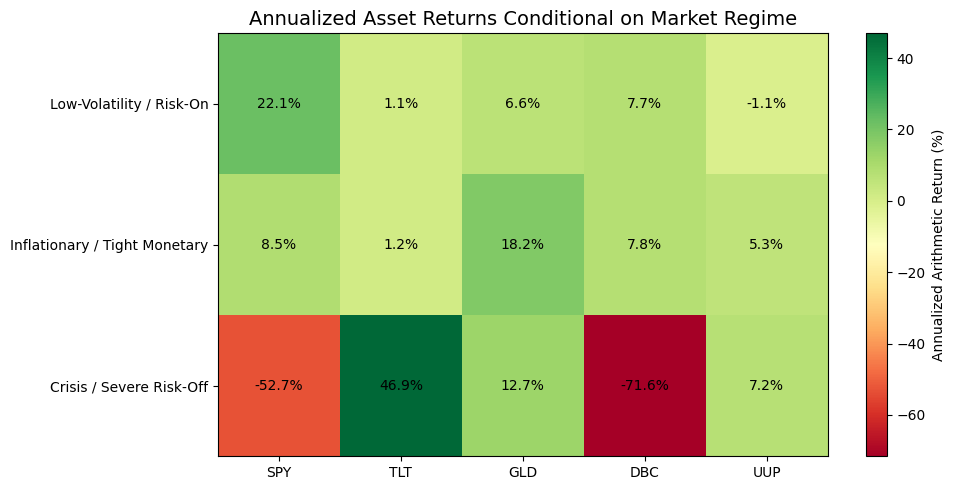

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))

heatmap_data = annualized_returns.values

im = ax.imshow(
    heatmap_data,
    aspect="auto",
    cmap="RdYlGn"
)

ax.set_xticks(np.arange(len(asset_tickers)))
ax.set_xticklabels(asset_tickers)

ax.set_yticks(
    np.arange(len(annualized_returns.index))
)
ax.set_yticklabels(
    annualized_returns.index
)

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        ax.text(
            j,
            i,
            f"{heatmap_data[i, j]:.1f}%",
            ha="center",
            va="center"
        )

ax.set_title(
    "Annualized Asset Returns Conditional on Market Regime",
    fontsize=14
)

fig.colorbar(
    im,
    ax=ax,
    label="Annualized Arithmetic Return (%)"
)

plt.tight_layout()
plt.show()

### Key Findings

- **Low-Volatility / Risk-On:** U.S. equities exhibit the strongest performance among the analyzed assets.
- **Inflationary / Tight Monetary:** Gold exhibits the strongest return and return-to-volatility ratio.
- **Crisis / Severe Risk-Off:** Long-term U.S. Treasuries perform strongly while equities and broad commodities experience sharply negative returns.

These results indicate that the relative attractiveness of major asset classes changes substantially across the market environments identified by the model.

## 13. Regime Persistence and Transition Probabilities

To examine the persistence of the identified market environments, one-day transition probabilities are calculated from the sequence of daily regime classifications.

Each row represents the current regime, while each column represents the regime observed on the following trading day.

High diagonal probabilities indicate that market regimes tend to persist rather than switch randomly from day to day.

In [27]:
current_regime = final_model_data["Regime"].iloc[:-1].values
next_regime = final_model_data["Regime"].iloc[1:].values

transition_matrix = pd.crosstab(
    current_regime,
    next_regime,
    normalize="index"
) * 100

transition_matrix.index = transition_matrix.index.map(regime_names)
transition_matrix.columns = transition_matrix.columns.map(regime_names)

transition_matrix.index.name = "Regime"
transition_matrix.columns.name = None

print("Regime Transition Probabilities (%)")
display(transition_matrix.round(2))

Regime Transition Probabilities (%)


,Low-Volatility / Risk-On,Inflationary / Tight Monetary,Crisis / Severe Risk-Off
Regime,,,
Low-Volatility / Risk-On,99.43,0.08,0.49
Inflationary / Tight Monetary,0.06,99.71,0.23
Crisis / Severe Risk-Off,4.36,0.93,94.70


## 14. Robustness to K-Means Initialization

Because K-Means begins with randomly initialized cluster centroids, different initializations can potentially produce different cluster assignments.

To evaluate the stability of the identified regimes, the model is re-estimated using several different random seeds. Each resulting clustering is compared with the baseline model using the **Adjusted Rand Index (ARI)**.

The ARI measures similarity between two cluster assignments while accounting for chance. A score of 1 indicates identical clustering, while values near 0 indicate little agreement beyond chance.

In [28]:
from sklearn.metrics import adjusted_rand_score

seeds = [0, 1, 10, 42, 100]

stability_results = []

baseline_labels = final_labels

for seed in seeds:

    test_model = KMeans(
        n_clusters=3,
        random_state=seed,
        n_init=20
    )

    test_labels = test_model.fit_predict(X_pca)

    ari = adjusted_rand_score(
        baseline_labels,
        test_labels
    )

    stability_results.append({
        "Random Seed": seed,
        "Adjusted Rand Index": ari
    })

stability_df = pd.DataFrame(stability_results)

stability_df

,Random Seed,Adjusted Rand Index
0,0,1.0
1,1,1.0
2,10,1.0
3,42,1.0
4,100,1.0


In [29]:
print(
    "Minimum ARI:",
    round(stability_df["Adjusted Rand Index"].min(), 4)
)

print(
    "Average ARI:",
    round(stability_df["Adjusted Rand Index"].mean(), 4)
)

Minimum ARI: 1.0
Average ARI: 1.0


### Robustness Result

The three-regime solution is stable across the tested K-Means initializations. All five alternative random seeds produce an **Adjusted Rand Index of 1.00** relative to the baseline model, indicating identical cluster assignments across the tested initializations.

This result suggests that the identified clustering structure is not driven by a particular random initialization of K-Means.

## 15. Limitations

Several limitations should be considered when interpreting the results.

**Ex-post classification.** The analysis identifies regimes using the full historical sample. PCA, feature standardization, and K-Means are fitted using the complete dataset, meaning the current results should be interpreted as historical classification rather than a real-time trading signal. In addition, the macroeconomic series may contain subsequently revised historical data rather than real-time data vintages available to investors at each date.

**No strategy backtest.** Although asset returns differ substantially across regimes, this analysis does not assume that an investor could have known each regime contemporaneously or switched assets without delay.

**Cluster interpretation.** K-Means produces numerical clusters rather than economically defined regimes. Labels such as "Risk-On" and "Crisis" are assigned after examining the characteristics of each cluster.

**Model specification.** Results depend on the selected features, lookback windows, PCA specification, number of clusters, and historical sample.

**Historical relationships may change.** Asset behavior observed within past regimes may not persist in future market environments.

These limitations distinguish regime identification from regime prediction and prevent the historical results from being interpreted as evidence of a directly tradable strategy.

## 16. Conclusion

This project investigates whether unsupervised machine learning can identify economically meaningful market regimes from macroeconomic and cross-asset financial data.

Using 13 market and macroeconomic features, PCA reduces the feature space to seven principal components while retaining approximately **92.2% of total variance**. Silhouette analysis supports a three-cluster K-Means solution, producing three interpretable market regimes:

1. **Low-Volatility / Risk-On**
2. **Inflationary / Tight Monetary**
3. **Crisis / Severe Risk-Off**

The identified regimes correspond to distinct financial and macroeconomic environments and align intuitively with several recognizable historical episodes. Lehman Brothers' bankruptcy, the 2011 U.S. credit downgrade, and the March 2020 COVID crash fall within the Crisis / Severe Risk-Off regime, while the June 2022 inflation and rate-hike environment falls within the Inflationary / Tight Monetary regime.

Cross-asset analysis reveals substantial differences in historical asset behavior across regimes. U.S. equities exhibit their strongest performance during Risk-On conditions, gold performs particularly well during Inflationary / Tight Monetary conditions, and long-term U.S. Treasuries exhibit strong performance during Crisis conditions.

The identified regimes are also highly persistent from one trading day to the next, while robustness testing indicates that the clustering solution is stable across the tested K-Means initializations.

Overall, the results suggest that unsupervised learning can organize complex financial and macroeconomic information into distinct and interpretable historical market environments. The framework provides a foundation for further research into real-time regime detection, out-of-sample validation, and regime-aware portfolio construction.

---

## 17. Future Research

This analysis establishes a historical market-regime classification framework, but several extensions could make the framework more useful for investment decision-making.

Potential next steps include:

- **Rolling or expanding-window estimation** to classify regimes using only information available at each point in time
- **Out-of-sample testing** to evaluate whether the regime structure generalizes beyond the estimation period
- **Regime-aware portfolio construction** to test whether asset allocation based on detected regimes improves risk-adjusted performance
- **Transaction costs and implementation delays** to evaluate realistic portfolio performance
- **Alternative clustering methods**, including Gaussian mixture models and hidden Markov models, to compare regime identification approaches
- **Additional features**, such as credit spreads, market breadth, earnings conditions, and liquidity indicators

These extensions would shift the framework from historical regime identification toward a genuinely predictive and investable system.